In [1]:
import time
import warnings
from aci.components.precipitation_bis import PrecipitationComponent
from dask.diagnostics import ProgressBar   # ← progress bar helper

t0 = time.perf_counter()                   # start timer

# ── Instantiate component ────────────────────────────────────────────────
precipitation = PrecipitationComponent(
    precipitation_data_path="ACI-Python/data/required_data/precipitation",
    mask_path="ACI-Python/data/required_data/mask_BEL.nc"
)

# ── Calculate SPI (still lazy / dask) ─────────────────────────────────────
precipitation_index = precipitation.calculate_component(
    reference_period=("1961-01-01", "1990-12-31"),
    area=True
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Compute with progress bar ─────────────────────────────────────────────
with ProgressBar():
    precipitation_index_computed = precipitation_index.compute()

precipitation_index_cleaned = precipitation_index_computed.sel(
    time=slice("1961-01-01", None)
)

# ── Output ─────────────────────────────────────────────────
print("✅ Precipitation Index calculated successfully!\n")
print(precipitation_index)

# ── Save cleaned SPI ─────────────────────────────────────────────────────
output_path = "ACI-Python/data/composites/precipitation_index.nc"
print(f"Saving Precipitation Index to {output_path}…")
precipitation_index_cleaned.to_netcdf(output_path)

# ── Stats ────────────────────────────────────────────────────────────────────
print("\n📊 Summary Statistics:")
print(f"Min:   {precipitation_index_computed.min().item():.3f}")
print(f"Max:   {precipitation_index_computed.max().item():.3f}")
print(f"Mean:  {precipitation_index_computed.mean().item():.3f}")
print(f"Std:   {precipitation_index_computed.std().item():.3f}")
print(f"NaNs:  {int(precipitation_index_computed.isnull().sum())}")

# ── Timer ────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")


[########################################] | 100% Completed | 3.23 sms
✅ Precipitation Index calculated successfully!

<xarray.DataArray 'precipitation_index' (time: 769)> Size: 6kB
dask.array<truediv, shape=(769,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    number   int64 8B 0
    surface  float64 8B 0.0
  * time     (time) datetime64[ns] 6kB 1960-12-31 1961-01-31 ... 2024-12-31
    month    (time) int64 6kB 12 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Saving Precipitation Index to ACI-Python/data/composites/precipitation_index.nc…

📊 Summary Statistics:
Min:   -2.567
Max:   6.599
Mean:  0.092
Std:   1.105
NaNs:  0

⏱️  Total run time: 4.60 seconds


In [1]:
# Compute area-mean t90 for Belgium — quiet, resilient, ASCII progress bar (no trimming)

import os
import time
import warnings
import logging
import xarray as xr
import numpy as np
import dask
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# ── Quiet runtime & macOS BLAS caps ───────────────────────────────────────────
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")  # macOS Accelerate
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

warnings.filterwarnings("ignore")
for name in ("distributed", "tornado", "fiona", "shapely", "cartopy", "bokeh"):
    logging.getLogger(name).setLevel(logging.CRITICAL)
logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────────
TEMP_INPUT_DIR   = "ACI-Python/data/required_data/temperature"
MASK_COMPAT      = "ACI-Python/data/required_data/mask_BEL.nc"   # var 'mask' (binary)
OUT_SERIES_PATH  = "ACI-Python/data/composites/t90_index.nc"     # NOTE: not *_grid.nc

REF_PERIOD = ("1961-01-01", "1990-12-31")
TIME_SLICE = ("1961-01-01", None)

TIME_CHUNK = 180   # consistent with gridded script
COMP_LEVEL = 0     # fastest write
CROP_TO_MASK = False  # keep full domain (no trimming)

os.makedirs(os.path.dirname(OUT_SERIES_PATH), exist_ok=True)

# ── Dask client: same parallel profile + sturdier comms ───────────────────────
client = Client(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="3.3GB",
    dashboard_address=None,
)
try:
    print(f"Dask client: {len(client.nthreads())} workers (dashboard disabled)")
except Exception:
    print("Dask client running (dashboard disabled)")

# Harden network layer & resilience
dask.config.set({
    "distributed.worker.memory.target": 0.80,
    "distributed.worker.memory.spill":  0.90,
    "distributed.worker.memory.pause":  0.96,
    "distributed.worker.memory.terminate": 0.98,
    "distributed.comm.compression": "auto",
    "distributed.comm.timeouts.connect": "60s",
    "distributed.comm.timeouts.tcp": "120s",
    "distributed.scheduler.default-task-retries": 2,  # retry transient failures
    "array.chunk-size": "128MiB",
    "array.chunk-size-tolerance": 1.5,
    "array.query-planning": False,
    "optimization.fuse.active": True,
    "logging.distributed": "critical",
    "logging.tornado": "critical",
})

def _quiet():
    import logging, warnings, os
    warnings.filterwarnings("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"
    for name in ("distributed", "tornado", "bokeh", "asyncio", "numba"):
        logging.getLogger(name).setLevel(logging.CRITICAL)
    logging.getLogger().setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker.memory").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
    logging.getLogger("tornado.application").setLevel(logging.CRITICAL)

client.run(_quiet)
client.run_on_scheduler(_quiet)

# ── Import component ──────────────────────────────────────────────────────────
try:
    from aci.components.temperature_bis import TemperatureComponent
except Exception:
    from aci.components.temperature import TemperatureComponent

temp90 = TemperatureComponent(
    temperature_data_path=TEMP_INPUT_DIR,
    mask_path=MASK_COMPAT,
    percentile=90,
    extremum="max",
    above_thresholds=True,
)

# ── Helpers for coords / optional early crop (kept identical) ────────────────
def _coord_names(obj):
    lat = "latitude" if "latitude" in obj.coords else ("lat" if "lat" in obj.coords else None)
    lon = "longitude" if "longitude" in obj.coords else ("lon" if "lon" in obj.coords else None)
    return lat, lon

def _wrap_to_180(da, lon_name):
    try:
        if float(da[lon_name].max()) > 180:
            return da.assign_coords({lon_name: ((da[lon_name] + 180) % 360) - 180}).sortby(lon_name)
    except Exception:
        pass
    return da

def _slice(values, vmin, vmax):
    return slice(vmin, vmax) if values[0] <= values[-1] else slice(vmax, vmin)

if CROP_TO_MASK:
    mds = None
    try:
        mds = xr.open_dataset(MASK_COMPAT)
        mvar = next(v for v in ("mask", "MASK", "Mask") if v in mds)
        m = mds[mvar]
        mlat, mlon = _coord_names(m)
        m = _wrap_to_180(m, mlon)
        m1 = m.where(m > 0.5, drop=True)
        lat_min, lat_max = float(m1[mlat].min()), float(m1[mlat].max())
        lon_min, lon_max = float(m1[mlon].min()), float(m1[mlon].max())

        A = getattr(temp90, "array", None)
        if isinstance(A, (xr.DataArray, xr.Dataset)):
            alat, alon = _coord_names(A)
            if alat and alon:
                A = _wrap_to_180(A, alon)
                temp90.array = A.sel({alat: _slice(A[alat].values, lat_min, lat_max),
                                      alon: _slice(A[alon].values, lon_min, lon_max)})
    except Exception:
        pass
    finally:
        try:
            if mds is not None:
                mds.close()
        except Exception:
            pass

# ── Chunk input for performance (time-parallel) ──────────────────────────────
if hasattr(temp90, "array"):
    try:
        arr = temp90.array
        if isinstance(arr, (xr.DataArray, xr.Dataset)) and "time" in arr.dims:
            chunks = {"time": TIME_CHUNK}
            for d in ("latitude", "lat", "longitude", "lon", "step"):
                if d in arr.dims: chunks[d] = -1
            temp90.array = arr.chunk(chunks)
    except Exception:
        pass

# ── Build computation graph (AREA MEAN series) ───────────────────────────────
try:
    t90_graph = temp90.calculate_component(reference_period=REF_PERIOD, area=True, apply_mask=True)
except TypeError:
    t90_graph = temp90.calculate_component(reference_period=REF_PERIOD, area=True)

# Ensure time-chunked output
try:
    if isinstance(t90_graph, xr.DataArray):
        t90_graph = t90_graph.chunk({"time": TIME_CHUNK})
    else:
        any_var = next(iter(t90_graph.data_vars))
        t90_graph = t90_graph[any_var].chunk({"time": TIME_CHUNK})
except Exception:
    pass

# ── Compute with retries + ASCII progress; graceful fallback ─────────────────
expr = t90_graph.sel(time=slice(*TIME_SLICE)).astype("float32")

def _compute_with_progress(e):
    """Try distributed compute with progress; fall back to local ProgressBar on any exception."""
    try:
        from dask.distributed import progress as dask_progress
        # annotate per-task retries in addition to global default
        import dask as _d
        with _d.annotate(retries=2):
            fut = client.compute(e)
        dask_progress(fut, notebook=False)
        return fut.result()
    except Exception:
        from dask.diagnostics import ProgressBar as _PB
        with _PB():
            return e.compute()

t90_index = _compute_with_progress(expr)

# Collapse "step" if present
if "step" in getattr(t90_index, "dims", []):
    t90_index = t90_index.mean("step", skipna=True)

# ── Canonical name and tidy coords ────────────────────────────────────────────
if isinstance(t90_index, xr.Dataset):
    main_var = next(iter(t90_index.data_vars))
    t90_index = t90_index.rename({main_var: "t90_index"})["t90_index"]
else:
    t90_index = t90_index.rename("t90_index")

for drop_name in ("valid_time", "expver", "number", "surface"):
    try:
        if drop_name in t90_index.coords:
            t90_index = t90_index.drop_vars(drop_name)
    except Exception:
        pass

# ── Save (fast writer) ───────────────────────────────────────────────────────
encoding = {"t90_index": {"zlib": (COMP_LEVEL > 0), "complevel": COMP_LEVEL, "dtype": "float32"}}
try:
    t90_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding, engine="h5netcdf")
except Exception:
    t90_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding)

print(f"✅ Saved area-mean t90 index to {OUT_SERIES_PATH}")

# ── Quick validity summary ───────────────────────────────────────────────────
n_total = int(t90_index.size); n_valid = int(t90_index.count())
print(f"✅ valid timesteps: {n_valid}/{n_total}  ({n_valid/n_total*100:.2f}%)")

# ── Structure ────────────────────────────────────────────────────────────────
print("\nStructure of t90 series:")
try:
    print("  dims :", dict(t90_index.sizes))  # works for DataArray & Dataset
except Exception:
    # ultra‑safe fallback
    print("  dims :", {d: int(t90_index.shape[i]) for i, d in enumerate(t90_index.dims)})

if "time" in t90_index.coords:
    c = t90_index.coords["time"].values
    if c.size:
        print(f"  time: {str(c[0])} → {str(c[-1])}  (len={c.size})")

# ── Stats ────────────────────────────────────────────────────────────────────
print("\n📊 Summary Statistics:")
print(f"Min:   {t90_index.min().item():.3f}")
print(f"Max:   {t90_index.max().item():.3f}")
print(f"Mean:  {t90_index.mean().item():.3f}")
print(f"Std:   {t90_index.std().item():.3f}")
print(f"NaNs:  {int(t90_index.isnull().sum())}")

# ── Timer & cleanup ──────────────────────────────────────────────────────────
print(f"\n⏱️ t90 computation time: {time.perf_counter() - t0:.2f} s")
try:
    client.close()
except Exception:
    pass

Dask client: 10 workers (dashboard disabled)
✅ Saved area-mean t90 index to ACI-Python/data/composites/t90_index.nc.0s
✅ valid timesteps: 768/768  (100.00%)

Structure of t90 series:
  dims : {'time': 768}
  time: 1961-01-31T00:00:00.000000000 → 2024-12-31T00:00:00.000000000  (len=768)

📊 Summary Statistics:
Min:   -2.452
Max:   4.159
Mean:  0.401
Std:   1.179
NaNs:  0

⏱️ t90 computation time: 503.95 s


In [1]:
# Compute area-mean t10 for Belgium — quiet, resilient, ASCII progress bar (no trimming)

import os
import time
import warnings
import logging
import xarray as xr
import numpy as np
import dask
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# ── Quiet runtime & macOS BLAS caps ───────────────────────────────────────────
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")  # macOS Accelerate
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

warnings.filterwarnings("ignore")
for name in ("distributed", "tornado", "fiona", "shapely", "cartopy", "bokeh"):
    logging.getLogger(name).setLevel(logging.CRITICAL)
logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────────
TEMP_INPUT_DIR   = "ACI-Python/data/required_data/temperature"
MASK_COMPAT      = "ACI-Python/data/required_data/mask_BEL.nc"   # var 'mask' (binary)
OUT_SERIES_PATH  = "ACI-Python/data/composites/t10_index.nc"     # NOTE: not *_grid.nc

REF_PERIOD = ("1961-01-01", "1990-12-31")
TIME_SLICE = ("1961-01-01", None)

TIME_CHUNK = 180   # consistent with gridded script
COMP_LEVEL = 0     # fastest write
CROP_TO_MASK = False  # keep full domain (no trimming)

os.makedirs(os.path.dirname(OUT_SERIES_PATH), exist_ok=True)

# ── Dask client: same parallel profile + sturdier comms ───────────────────────
client = Client(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="3.3GB",
    dashboard_address=None,
)
try:
    print(f"Dask client: {len(client.nthreads())} workers (dashboard disabled)")
except Exception:
    print("Dask client running (dashboard disabled)")

# Harden network layer & resilience
dask.config.set({
    "distributed.worker.memory.target": 0.80,
    "distributed.worker.memory.spill":  0.90,
    "distributed.worker.memory.pause":  0.96,
    "distributed.worker.memory.terminate": 0.98,
    "distributed.comm.compression": "auto",
    "distributed.comm.timeouts.connect": "60s",
    "distributed.comm.timeouts.tcp": "120s",
    "distributed.scheduler.default-task-retries": 2,  # retry transient failures
    "array.chunk-size": "128MiB",
    "array.chunk-size-tolerance": 1.5,
    "array.query-planning": False,
    "optimization.fuse.active": True,
    "logging.distributed": "critical",
    "logging.tornado": "critical",
})

def _quiet():
    import logging, warnings, os
    warnings.filterwarnings("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"
    for name in ("distributed", "tornado", "bokeh", "asyncio", "numba"):
        logging.getLogger(name).setLevel(logging.CRITICAL)
    logging.getLogger().setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker.memory").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
    logging.getLogger("tornado.application").setLevel(logging.CRITICAL)

client.run(_quiet)
client.run_on_scheduler(_quiet)

# ── Import component ──────────────────────────────────────────────────────────
try:
    from aci.components.temperature_bis import TemperatureComponent
except Exception:
    from aci.components.temperature import TemperatureComponent

# NOTE: t10 → 10th percentile of minima; count BELOW threshold
temp10 = TemperatureComponent(
    temperature_data_path=TEMP_INPUT_DIR,
    mask_path=MASK_COMPAT,
    percentile=10,
    extremum="min",
    above_thresholds=False,
)

# ── Helpers for coords / optional early crop (kept identical) ────────────────
def _coord_names(obj):
    lat = "latitude" if "latitude" in obj.coords else ("lat" if "lat" in obj.coords else None)
    lon = "longitude" if "longitude" in obj.coords else ("lon" if "lon" in obj.coords else None)
    return lat, lon

def _wrap_to_180(da, lon_name):
    try:
        if float(da[lon_name].max()) > 180:
            return da.assign_coords({lon_name: ((da[lon_name] + 180) % 360) - 180}).sortby(lon_name)
    except Exception:
        pass
    return da

def _slice(values, vmin, vmax):
    return slice(vmin, vmax) if values[0] <= values[-1] else slice(vmax, vmin)

if CROP_TO_MASK:
    mds = None
    try:
        mds = xr.open_dataset(MASK_COMPAT)
        mvar = next(v for v in ("mask", "MASK", "Mask") if v in mds)
        m = mds[mvar]
        mlat, mlon = _coord_names(m)
        m = _wrap_to_180(m, mlon)
        m1 = m.where(m > 0.5, drop=True)
        lat_min, lat_max = float(m1[mlat].min()), float(m1[mlat].max())
        lon_min, lon_max = float(m1[mlon].min()), float(m1[mlon].max())

        A = getattr(temp10, "array", None)
        if isinstance(A, (xr.DataArray, xr.Dataset)):
            alat, alon = _coord_names(A)
            if alat and alon:
                A = _wrap_to_180(A, alon)
                temp10.array = A.sel({alat: _slice(A[alat].values, lat_min, lat_max),
                                      alon: _slice(A[alon].values, lon_min, lon_max)})
    except Exception:
        pass
    finally:
        try:
            if mds is not None:
                mds.close()
        except Exception:
            pass

# ── Chunk input for performance (time-parallel) ──────────────────────────────
if hasattr(temp10, "array"):
    try:
        arr = temp10.array
        if isinstance(arr, (xr.DataArray, xr.Dataset)) and "time" in arr.dims:
            chunks = {"time": TIME_CHUNK}
            for d in ("latitude", "lat", "longitude", "lon", "step"):
                if d in arr.dims: chunks[d] = -1
            temp10.array = arr.chunk(chunks)
    except Exception:
        pass

# ── Build computation graph (AREA MEAN series) ───────────────────────────────
try:
    t10_graph = temp10.calculate_component(reference_period=REF_PERIOD, area=True, apply_mask=True)
except TypeError:
    t10_graph = temp10.calculate_component(reference_period=REF_PERIOD, area=True)

# Ensure time-chunked output
try:
    if isinstance(t10_graph, xr.DataArray):
        t10_graph = t10_graph.chunk({"time": TIME_CHUNK})
    else:
        any_var = next(iter(t10_graph.data_vars))
        t10_graph = t10_graph[any_var].chunk({"time": TIME_CHUNK})
except Exception:
    pass

# ── Compute with retries + ASCII progress; graceful fallback ─────────────────
expr = t10_graph.sel(time=slice(*TIME_SLICE)).astype("float32")

def _compute_with_progress(e):
    """Try distributed compute with progress; fall back to local ProgressBar on any exception."""
    try:
        from dask.distributed import progress as dask_progress
        import dask as _d
        with _d.annotate(retries=2):
            fut = client.compute(e)
        dask_progress(fut, notebook=False)
        return fut.result()
    except Exception:
        from dask.diagnostics import ProgressBar as _PB
        with _PB():
            return e.compute()

t10_index = _compute_with_progress(expr)

# Collapse "step" if present
if "step" in getattr(t10_index, "dims", []):
    t10_index = t10_index.mean("step", skipna=True)

# ── Canonical name and tidy coords ────────────────────────────────────────────
if isinstance(t10_index, xr.Dataset):
    main_var = next(iter(t10_index.data_vars))
    t10_index = t10_index.rename({main_var: "t10_index"})["t10_index"]
else:
    t10_index = t10_index.rename("t10_index")

for drop_name in ("valid_time", "expver", "number", "surface"):
    try:
        if drop_name in t10_index.coords:
            t10_index = t10_index.drop_vars(drop_name)
    except Exception:
        pass

# ── Save (fast writer) ───────────────────────────────────────────────────────
encoding = {"t10_index": {"zlib": (COMP_LEVEL > 0), "complevel": COMP_LEVEL, "dtype": "float32"}}
try:
    t10_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding, engine="h5netcdf")
except Exception:
    t10_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding)

print(f"✅ Saved area-mean t10 index to {OUT_SERIES_PATH}")

# ── Quick validity summary ───────────────────────────────────────────────────
n_total = int(t10_index.size); n_valid = int(t10_index.count())
print(f"✅ valid timesteps: {n_valid}/{n_total}  ({n_valid/n_total*100:.2f}%)")

# ── Structure ────────────────────────────────────────────────────────────────
print("\nStructure of t10 series:")
try:
    print("  dims :", dict(t10_index.sizes))  # works for DataArray & Dataset
except Exception:
    print("  dims :", {d: int(t10_index.shape[i]) for i, d in enumerate(t10_index.dims)})

if "time" in t10_index.coords:
    c = t10_index.coords["time"].values
    if c.size:
        print(f"  time: {str(c[0])} → {str(c[-1])}  (len={c.size})")

# ── Stats ────────────────────────────────────────────────────────────────────
print("\n📊 Summary Statistics:")
print(f"Min:   {t10_index.min().item():.3f}")
print(f"Max:   {t10_index.max().item():.3f}")
print(f"Mean:  {t10_index.mean().item():.3f}")
print(f"Std:   {t10_index.std().item():.3f}")
print(f"NaNs:  {int(t10_index.isnull().sum())}")

# ── Timer & cleanup ──────────────────────────────────────────────────────────
print(f"\n⏱️ t10 computation time: {time.perf_counter() - t0:.2f} s")
try:
    client.close()
except Exception:
    pass


Dask client: 10 workers (dashboard disabled)
✅ Saved area-mean t10 index to ACI-Python/data/composites/t10_index.nc.9s
✅ valid timesteps: 768/768  (100.00%)

Structure of t10 series:
  dims : {'time': 768}
  time: 1961-01-31T00:00:00.000000000 → 2024-12-31T00:00:00.000000000  (len=768)

📊 Summary Statistics:
Min:   -2.285
Max:   3.126
Mean:  -0.326
Std:   1.002
NaNs:  0

⏱️ t10 computation time: 507.97 s


In [1]:
# Compute area-mean WIND for Belgium — quiet, resilient, ASCII progress bar (no trimming)

import os
import time
import warnings
import logging
import inspect
import xarray as xr
import numpy as np
import dask
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# ── Quiet runtime & macOS BLAS caps ───────────────────────────────────────────
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")  # macOS Accelerate
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

warnings.filterwarnings("ignore")
for name in ("distributed", "tornado", "fiona", "shapely", "cartopy", "bokeh"):
    logging.getLogger(name).setLevel(logging.CRITICAL)
logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────────
WIND_U10_INPUT_DIR = "ACI-Python/data/required_data/wind_u10"
WIND_V10_INPUT_DIR = "ACI-Python/data/required_data/wind_v10"
MASK_COMPAT        = "ACI-Python/data/required_data/mask_BEL.nc"   # var 'mask' (binary)
OUT_SERIES_PATH    = "ACI-Python/data/composites/wind_index.nc"    # area-mean series

REF_PERIOD = ("1961-01-01", "1990-12-31")
TIME_SLICE = ("1961-01-01", None)

TIME_CHUNK = 180   # consistent with temperature scripts
COMP_LEVEL = 0     # fastest write
CROP_TO_MASK = False  # keep full domain (no trimming)

os.makedirs(os.path.dirname(OUT_SERIES_PATH), exist_ok=True)

# ── Dask client: same parallel profile + sturdier comms ───────────────────────
client = Client(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="3.3GB",
    dashboard_address=None,
)
try:
    print(f"Dask client: {len(client.nthreads())} workers (dashboard disabled)")
except Exception:
    print("Dask client running (dashboard disabled)")

# Harden network layer & resilience
dask.config.set({
    "distributed.worker.memory.target": 0.80,
    "distributed.worker.memory.spill":  0.90,
    "distributed.worker.memory.pause":  0.96,
    "distributed.worker.memory.terminate": 0.98,
    "distributed.comm.compression": "auto",
    "distributed.comm.timeouts.connect": "60s",
    "distributed.comm.timeouts.tcp": "120s",
    "distributed.scheduler.default-task-retries": 2,  # retry transient failures
    "array.chunk-size": "128MiB",
    "array.chunk-size-tolerance": 1.5,
    "array.query-planning": False,
    "optimization.fuse.active": True,
    "logging.distributed": "critical",
    "logging.tornado": "critical",
})

def _quiet():
    import logging, warnings, os
    warnings.filterwarnings("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"
    for name in ("distributed", "tornado", "bokeh", "asyncio", "numba"):
        logging.getLogger(name).setLevel(logging.CRITICAL)
    logging.getLogger().setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.worker.memory").setLevel(logging.CRITICAL)
    logging.getLogger("distributed.comm").setLevel(logging.CRITICAL)
    logging.getLogger("tornado.application").setLevel(logging.CRITICAL)

client.run(_quiet)
client.run_on_scheduler(_quiet)

# ── Import component ──────────────────────────────────────────────────────────
try:
    from aci.components.wind_bis import WindComponent
except Exception:
    from aci.components.wind import WindComponent

# Robust constructor: adapt to whatever __init__ accepts (no positional guesses)
def _build_wind_component():
    sig = inspect.signature(WindComponent.__init__)
    params = set(sig.parameters) - {"self"}
    kw = {}

    # paths
    if "wind_u10_data_path" in params:
        kw["wind_u10_data_path"] = WIND_U10_INPUT_DIR
    elif "u10_data_path" in params:
        kw["u10_data_path"] = WIND_U10_INPUT_DIR
    elif "u10_path" in params:
        kw["u10_path"] = WIND_U10_INPUT_DIR

    if "wind_v10_data_path" in params:
        kw["wind_v10_data_path"] = WIND_V10_INPUT_DIR
    elif "v10_data_path" in params:
        kw["v10_data_path"] = WIND_V10_INPUT_DIR
    elif "v10_path" in params:
        kw["v10_path"] = WIND_V10_INPUT_DIR

    # common options
    if "mask_path" in params:
        kw["mask_path"] = MASK_COMPAT
    if "percentile" in params:
        kw["percentile"] = 90
    if "above_thresholds" in params:
        kw["above_thresholds"] = True
    if "extremum" in params:
        # some APIs might accept 'speed'; others ignore it
        kw["extremum"] = "speed"

    try:
        return WindComponent(**kw)
    except TypeError as e:
        # Make the error actionable but still concise
        raise TypeError(
            f"WindComponent constructor mismatch. Provided kwargs: {kw}. "
            f"Init signature: {sig}"
        ) from e

wind90 = _build_wind_component()

# ── Helpers for coords / optional early crop (kept identical) ────────────────
def _coord_names(obj):
    lat = "latitude" if "latitude" in obj.coords else ("lat" if "lat" in obj.coords else None)
    lon = "longitude" if "longitude" in obj.coords else ("lon" if "lon" in obj.coords else None)
    return lat, lon

def _wrap_to_180(da, lon_name):
    try:
        if float(da[lon_name].max()) > 180:
            return da.assign_coords({lon_name: ((da[lon_name] + 180) % 360) - 180}).sortby(lon_name)
    except Exception:
        pass
    return da

def _slice(values, vmin, vmax):
    return slice(vmin, vmax) if values[0] <= values[-1] else slice(vmax, vmin)

# Attempt early crop on any obvious arrays (if exposed by component)
if CROP_TO_MASK:
    mds = None
    try:
        mds = xr.open_dataset(MASK_COMPAT)
        mvar = next(v for v in ("mask", "MASK", "Mask") if v in mds)
        m = mds[mvar]
        mlat, mlon = _coord_names(m)
        m = _wrap_to_180(m, mlon)
        m1 = m.where(m > 0.5, drop=True)
        lat_min, lat_max = float(m1[mlat].min()), float(m1[mlat].max())
        lon_min, lon_max = float(m1[mlon].min()), float(m1[mlon].max())

        A = getattr(wind90, "array", None)
        if isinstance(A, (xr.DataArray, xr.Dataset)):
            alat, alon = _coord_names(A)
            if alat and alon:
                A = _wrap_to_180(A, alon)
                wind90.array = A.sel({alat: _slice(A[alat].values, lat_min, lat_max),
                                      alon: _slice(A[alon].values, lon_min, lon_max)})
        else:
            for name in ("u10", "v10", "u", "v"):
                arr = getattr(wind90, name, None)
                if isinstance(arr, (xr.DataArray, xr.Dataset)):
                    alat, alon = _coord_names(arr)
                    if alat and alon:
                        arr = _wrap_to_180(arr, alon)
                        sel = arr.sel({alat: _slice(arr[alat].values, lat_min, lat_max),
                                       alon: _slice(arr[alon].values, lon_min, lon_max)})
                        setattr(wind90, name, sel)
    except Exception:
        pass
    finally:
        try:
            if mds is not None:
                mds.close()
        except Exception:
            pass

# ── Chunk input for performance (time-parallel) ──────────────────────────────
try:
    arr = getattr(wind90, "array", None)
    if isinstance(arr, (xr.DataArray, xr.Dataset)) and "time" in arr.dims:
        chunks = {"time": TIME_CHUNK}
        for d in ("latitude", "lat", "longitude", "lon", "step"):
            if d in arr.dims: chunks[d] = -1
        wind90.array = arr.chunk(chunks)
    else:
        for name in ("u10", "v10", "u", "v"):
            da = getattr(wind90, name, None)
            if isinstance(da, (xr.DataArray, xr.Dataset)) and "time" in da.dims:
                chunks = {"time": TIME_CHUNK}
                for d in ("latitude", "lat", "longitude", "lon", "step"):
                    if d in da.dims: chunks[d] = -1
                setattr(wind90, name, da.chunk(chunks))
except Exception:
    pass

# ── Build computation graph (AREA MEAN series) ───────────────────────────────
try:
    wind_graph = wind90.calculate_component(reference_period=REF_PERIOD, area=True, apply_mask=True)
except TypeError:
    wind_graph = wind90.calculate_component(reference_period=REF_PERIOD, area=True)

# Ensure time-chunked output
try:
    if isinstance(wind_graph, xr.DataArray):
        wind_graph = wind_graph.chunk({"time": TIME_CHUNK})
    else:
        any_var = next(iter(wind_graph.data_vars))
        wind_graph = wind_graph[any_var].chunk({"time": TIME_CHUNK})
except Exception:
    pass

# ── Compute with retries + ASCII progress; graceful fallback ─────────────────
expr = wind_graph.sel(time=slice(*TIME_SLICE)).astype("float32")

def _compute_with_progress(e):
    """Try distributed compute with progress; fall back to local ProgressBar on any exception."""
    try:
        from dask.distributed import progress as dask_progress
        import dask as _d
        with _d.annotate(retries=2):
            fut = client.compute(e)
        dask_progress(fut, notebook=False)
        return fut.result()
    except Exception:
        from dask.diagnostics import ProgressBar as _PB
        with _PB():
            return e.compute()

wind_index = _compute_with_progress(expr)

# Collapse "step" if present
if "step" in getattr(wind_index, "dims", []):
    wind_index = wind_index.mean("step", skipna=True)

# ── Canonical name and tidy coords ────────────────────────────────────────────
if isinstance(wind_index, xr.Dataset):
    main_var = next(iter(wind_index.data_vars))
    wind_index = wind_index.rename({main_var: "wind_index"})["wind_index"]
else:
    wind_index = wind_index.rename("wind_index")

for drop_name in ("valid_time", "expver", "number", "surface"):
    try:
        if drop_name in wind_index.coords:
            wind_index = wind_index.drop_vars(drop_name)
    except Exception:
        pass

# ── Save (fast writer) ───────────────────────────────────────────────────────
encoding = {"wind_index": {"zlib": (COMP_LEVEL > 0), "complevel": COMP_LEVEL, "dtype": "float32"}}
try:
    wind_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding, engine="h5netcdf")
except Exception:
    wind_index.to_netcdf(OUT_SERIES_PATH, encoding=encoding)

print(f"✅ Saved area-mean wind index to {OUT_SERIES_PATH}")

# ── Quick validity summary ───────────────────────────────────────────────────
n_total = int(wind_index.size); n_valid = int(wind_index.count())
print(f"✅ valid timesteps: {n_valid}/{n_total}  ({n_valid/n_total*100:.2f}%)")

# ── Structure ────────────────────────────────────────────────────────────────
print("\nStructure of wind series:")
try:
    print("  dims :", dict(wind_index.sizes))  # works for DataArray & Dataset
except Exception:
    print("  dims :", {d: int(wind_index.shape[i]) for i, d in enumerate(wind_index.dims)})

if "time" in wind_index.coords:
    c = wind_index.coords["time"].values
    if c.size:
        print(f"  time: {str(c[0])} → {str(c[-1])}  (len={c.size})")

# ── Stats ────────────────────────────────────────────────────────────────────
print("\n📊 Summary Statistics:")
print(f"Min:   {wind_index.min().item():.3f}")
print(f"Max:   {wind_index.max().item():.3f}")
print(f"Mean:  {wind_index.mean().item():.3f}")
print(f"Std:   {wind_index.std().item():.3f}")
print(f"NaNs:  {int(wind_index.isnull().sum())}")

# ── Timer & cleanup ──────────────────────────────────────────────────────────
print(f"\n⏱️ wind computation time: {time.perf_counter() - t0:.2f} s")
try:
    client.close()
except Exception:
    pass


Dask client: 10 workers (dashboard disabled)
✅ Saved area-mean wind index to ACI-Python/data/composites/wind_index.nc
✅ valid timesteps: 768/768  (100.00%)

Structure of wind series:
  dims : {'time': 768}
  time: 1961-01-31T00:00:00.000000000 → 2024-12-31T00:00:00.000000000  (len=768)

📊 Summary Statistics:
Min:   -1.697
Max:   4.675
Mean:  0.031
Std:   1.039
NaNs:  0

⏱️ wind computation time: 46.45 s


In [1]:
# run_sealevel_index.py
import os
import time
import warnings
import pandas as pd
import xarray as xr
from dask.diagnostics import ProgressBar

# If you placed the component here:
# from aci.components.sealevel_component_bis import SeaLevelComponent
# If you kept your filename as 'sealevel_bis.py', keep this:
from aci.components.sealevel_bis import SeaLevelComponent

# ── Config ───────────────────────────────────────────────────────────────
OUTPUT_PATH = "ACI-Python/data/composites/sealevel_index.nc"
REF_PERIOD  = ("1961-01-01", "1990-12-31")
STUDY_PER   = ("1961-01-01", "2024-12-31")
COUNTRY     = "BEL"

def ensure_month_end_index(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """Force month-end timestamps for alignment with other composites."""
    return pd.to_datetime(idx).to_period("M").to_timestamp("M")

def main():
    t0 = time.perf_counter()
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    # ── Instantiate + process ────────────────────────────────────────────
    sea = SeaLevelComponent(
        country_abrev=COUNTRY,
        study_period=STUDY_PER,
        reference_period=REF_PERIOD,
    )

    sealevel_index = sea.process()  # usually a pandas Series (month-end)

    # ── Compute if dask-backed; otherwise it's already in memory ─────────
    if hasattr(sealevel_index, "compute"):
        with ProgressBar():
            sealevel_index_computed = sealevel_index.compute()
    else:
        sealevel_index_computed = sealevel_index

    print("✅ Full Sea-Level Index calculated successfully!")
    print(sealevel_index_computed)

    # ── Stats summary over the FULL period ───────────────────────────────
    print("\nStats summary (1961–2024):")
    is_series = isinstance(sealevel_index_computed, pd.Series)

    if is_series:
        s = sealevel_index_computed
        # enforce month-end index for consistency
        s.index = ensure_month_end_index(s.index)
        min_val   = s.min()
        max_val   = s.max()
        mean_val  = s.mean()
        std_val   = s.std()
        nan_count = int(s.isna().sum())
        t_min, t_max, n = s.index.min(), s.index.max(), len(s)
    else:
        df = sealevel_index_computed
        # if it's a DataFrame, also force month-end index
        df.index = ensure_month_end_index(df.index)
        min_val   = df.min().min()
        max_val   = df.max().max()
        mean_val  = df.stack().mean()
        std_val   = df.stack().std()
        nan_count = int(df.isnull().sum().sum())
        t_min, t_max, n = df.index.min(), df.index.max(), len(df)

    print(f"start: {t_min:%Y-%m}, end: {t_max:%Y-%m}, n={n}")
    print(f"min:        {min_val:.3f}")
    print(f"max:        {max_val:.3f}")
    print(f"mean:       {mean_val:.3f}")
    print(f"std:        {std_val:.3f}")
    print(f"count NaNs: {nan_count}")

    # ── Save cleaned SSLI to NetCDF ──────────────────────────────────────
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    print(f"\nSaving Sea Level Index to {OUTPUT_PATH}…")

    if is_series:
        da = xr.DataArray(
            sealevel_index_computed.values,
            coords={"time": ensure_month_end_index(sealevel_index_computed.index)},
            dims="time",
            name="sealevel_index",
        )
        da.to_netcdf(OUTPUT_PATH)
    else:
        ds = sealevel_index_computed.to_xarray()
        # rename single var to 'sealevel_index' if needed
        if len(ds.data_vars) == 1:
            vname = next(iter(ds.data_vars))
            ds = ds.rename({vname: "sealevel_index"})
        ds.to_netcdf(OUTPUT_PATH)

    # ── Timer ────────────────────────────────────────────────────────────
    t1 = time.perf_counter()
    print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")

if __name__ == "__main__":
    main()


The directory rlr_monthly already exists. No action needed.
DataFrame loaded successfully.
✅ Full Sea-Level Index calculated successfully!
time
1961-01-31   -0.768190
1961-02-28    0.152333
1961-03-31    0.342185
1961-04-30   -1.179887
1961-05-31    0.816901
                ...   
2024-08-31    4.255334
2024-09-30    3.934356
2024-10-31    2.454609
2024-11-30    2.138789
2024-12-31    1.439368
Freq: ME, Name: sealevel_index, Length: 768, dtype: float64

Stats summary (1961–2024):
start: 1961-01, end: 2024-12, n=768
min:        -2.587
max:        5.471
mean:       0.797
std:        1.312
count NaNs: 0

Saving Sea Level Index to ACI-Python/data/composites/sealevel_index.nc…

⏱️  Total run time: 0.07 seconds


In [2]:
import xarray as xr, pandas as pd
ds = xr.open_dataset("ACI-Python/data/composites/sealevel_index.nc")
s  = ds["sealevel_index"].to_series()
s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
print(s.index.month.value_counts().sort_index())  # should show months 1..12 all with 64


time
1     64
2     64
3     64
4     64
5     64
6     64
7     64
8     64
9     64
10    64
11    64
12    64
Name: count, dtype: int64


In [1]:
import time
import warnings
from dask.diagnostics import ProgressBar
from aci.components.drought_bis import DroughtComponent

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Instantiate component ─────────────────────────────────────────────────
drought = DroughtComponent(
    precipitation_data_path="ACI-Python/data/required_data/precipitation",
    mask_path="ACI-Python/data/required_data/mask_BEL.nc"
)

# ── Calculate standardized drought index (lazy / dask) ────────────────────
drought_index = drought.calculate_component(
    reference_period=("1961-01-01", "1990-12-31"),
    area=True
)

# ── Suppress harmless warnings ────────────────────────────────────────────
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Compute with progress bar ─────────────────────────────────────────────
with ProgressBar():
    drought_index_computed = drought_index.compute()

# ── Clean time range (drop pre-1961 if exists) ────────────────────────────
drought_index_cleaned = drought_index_computed.sel(time=slice("1961-01-01", None))

# ── Print stats ───────────────────────────────────────────────────────────
print("✅ Drought Index calculated and cleaned successfully!")
print(drought_index_cleaned)
print("📊 Stats summary:")
print(f"min:        {drought_index_cleaned.min().item():.3f}")
print(f"max:        {drought_index_cleaned.max().item():.3f}")
print(f"mean:       {drought_index_cleaned.mean().item():.3f}")
print(f"std:        {drought_index_cleaned.std().item():.3f}")
print(f"count NaNs: {float(drought_index_cleaned.isnull().sum().values)}")

# ── Save cleaned SDI ─────────────────────────────────────────────────────
output_path = "ACI-Python/data/composites/drought_index.nc"
print(f"Saving Drought Index to {output_path}…")
drought_index_cleaned.to_netcdf(output_path)

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️  Total run time: {t1 - t0:.2f} seconds")

[########################################] | 100% Completed | 78.26 s
✅ Drought Index calculated and cleaned successfully!
<xarray.DataArray 'drought_index' (time: 768)> Size: 6kB
array([-8.73461742e-01, -4.86554480e-01,  8.54057024e-01, -1.13470997e+00,
        5.20725921e-01, -9.75536578e-02, -1.59298984e-01, -7.74827347e-02,
        6.43405629e-01, -4.35169631e-01, -3.52076649e-01,  7.41005062e-02,
       -4.00464223e-01, -3.43115956e-01,  5.80120608e-01, -4.81604575e-01,
        7.20532745e-01,  1.90410770e+00,  1.83561426e+00, -8.74725069e-01,
        1.13474026e-01,  1.20897624e+00, -4.23514749e-01,  5.60855525e-01,
        6.98087066e-01,  2.14038887e+00,  2.39540289e+00, -1.05253867e-01,
       -9.75363975e-01, -5.13318027e-01,  3.25427841e-01,  6.49949114e-01,
        2.22109099e-01, -1.10404211e-01, -6.39269081e-01,  2.11935799e+00,
        2.61070850e+00,  1.92382114e+00,  1.76126279e+00,  7.97772744e-01,
        1.95676055e+00,  5.94672682e-01,  2.10496206e-01,  1.14940242e

ℹ️  precip–drought correlation (post-orientation): -0.387 (expect negative if drought=‘drier positive’).

📏 Reference-period (1961–1990) sanity check (should be ~ mean≈0, std≈1):
      precipitation    t90    t10  drought   wind  sealevel
mean         -0.000 -0.000 -0.000   -0.000  0.000    -0.000
std           1.001  1.001  1.001    1.001  1.001     1.001

BACI composite calculated successfully! 📊 Stats summary:
min:        -1.462
max:        2.203
mean:       0.274
std:        0.584
count NaNs: 0

🔗 Correlation matrix between composites:
               precipitation    t90    t10  drought   wind  sealevel   BACI
precipitation          1.000 -0.048 -0.051   -0.387  0.377     0.345  0.433
t90                   -0.048  1.000 -0.730    0.139  0.007     0.327  0.698
t10                   -0.051 -0.730  1.000    0.030 -0.061    -0.403 -0.707
drought               -0.387  0.139  0.030    1.000 -0.277    -0.270  0.044
wind                   0.377  0.007 -0.061   -0.277  1.000     0.345  0.47

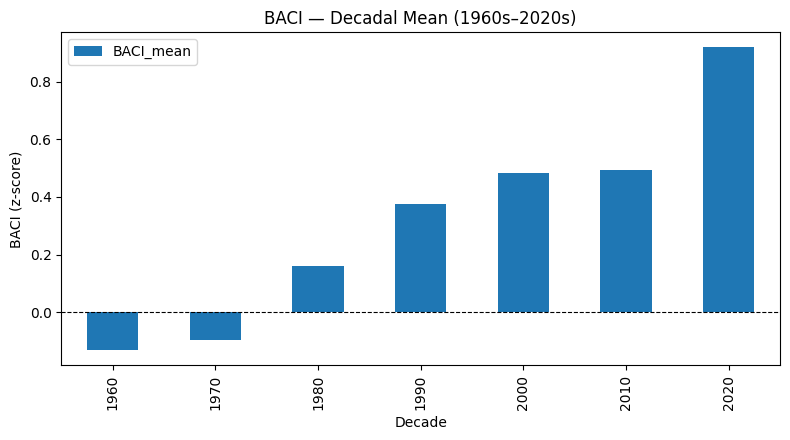

🖼️ Saved PNG → ACI-Python/data/composites/BACI_decadal_means.png
🧪 BACI fingerprint: {'mean': 0.27409226621375793, 'std': 0.5843940951495518, 'head': [-0.036153, 0.834808, 0.339282], 'tail': [0.582361, 0.6512, 0.54511]}
✅ fingerprint matches previous run.
⏱️ Run time: 0.16 s


In [2]:
import os
import time
from typing import Dict
import tempfile, shutil
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────
dir_path = "ACI-Python/data/composites"
paths: Dict[str, str] = {
    "precipitation": os.path.join(dir_path, "precipitation_index.nc"),
    "t90":           os.path.join(dir_path, "t90_index.nc"),
    "t10":           os.path.join(dir_path, "t10_index.nc"),
    "drought":       os.path.join(dir_path, "drought_index.nc"),
    "wind":          os.path.join(dir_path, "wind_index.nc"),
    "sealevel":      os.path.join(dir_path, "sealevel_index.nc"),
}

# Reference period for standardization sanity checks
REF_START, REF_END = "1961-01-31", "1990-12-31"

# Sea-level weight (can be varied in sensitivity section)
SEALEVEL_WEIGHT = 1.0

# If your "drought_index.nc" is SPI-like (positive=wet, negative=dry),
# set to True to flip it so that positive=drier
DROUGHT_IS_SPI = False

# Plot / export toggles
MAKE_DECADAL_PNG = True

# Fixed monthly grid (1961-01 → 2024-12, month-end timestamps)
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def _collapse_to_series(da: xr.DataArray, name: str) -> pd.Series:
    """Collapse non-time dims → mean (skipna), align to full_idx, name it."""
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    s = s.reindex(full_idx)
    s.name = name
    return s

def load_component_series(name: str, path: str) -> pd.Series:
    """Open DA/DS robustly and return an aligned monthly Series."""
    if name == "sealevel":
        ds = xr.open_dataset(path)
        da = ds.to_array().mean(dim="variable", skipna=True)
    else:
        try:
            da = xr.open_dataarray(path)
        except Exception:
            ds = xr.open_dataset(path)
            da = ds[name] if name in ds.data_vars else next(iter(ds.data_vars.values()))
    if "step" in da.dims:
        da = da.mean(dim="step")
    if "time" in da.coords:
        da = da.sel(time=slice("1961-01-01", None))
    return _collapse_to_series(da, name)

def build_baci(df: pd.DataFrame, sealevel_weight: float) -> pd.Series:
    return (
        df["t90"] - df["t10"]
        + df["precipitation"]
        + df["drought"]
        + sealevel_weight * df["sealevel"]
        + df["wind"]
    ) / 6.0

# ── Load & align ──────────────────────────────────────────────────────────
comp = {k: load_component_series(k, p) for k, p in paths.items()}
df = pd.DataFrame(comp, index=full_idx)

# ── Drought orientation (SPI-like?) ───────────────────────────────────────
if DROUGHT_IS_SPI:
    df["drought"] = -df["drought"]

# Quick diagnostic: precipitation–drought correlation
try:
    corr_pd = df[["precipitation", "drought"]].dropna().corr().iloc[0, 1]
    print(f"ℹ️  precip–drought correlation (post-orientation): {corr_pd:.3f} "
          f"(expect negative if drought=‘drier positive’).")
except Exception:
    pass

# ── Hardening guards ──────────────────────────────────────────────────────
nan_counts = df.isna().sum()
assert nan_counts.sum() == 0, f"Unexpected NaNs:\n{nan_counts}"
counts_by_month = pd.Series(df.index.month).value_counts().sort_index()
assert (counts_by_month == 64).all(), f"Unexpected monthly coverage:\n{counts_by_month}"

# ── Reference-period sanity check ─────────────────────────────────────────
ref_slice = df.loc[pd.to_datetime(REF_START):pd.to_datetime(REF_END),
                   ["precipitation", "t90", "t10", "drought", "wind", "sealevel"]]
ref_chk = ref_slice.agg(["mean", "std"])
print("\n📏 Reference-period (1961–1990) sanity check (should be ~ mean≈0, std≈1):")
print(ref_chk.round(3).to_string())

# ── Compute BACI ──────────────────────────────────────────────────────────
df["BACI"] = build_baci(df, SEALEVEL_WEIGHT)

# ── Stats summary ─────────────────────────────────────────────────────────
print("\nBACI composite calculated successfully! 📊 Stats summary:")
print(f"min:        {df['BACI'].min():.3f}")
print(f"max:        {df['BACI'].max():.3f}")
print(f"mean:       {df['BACI'].mean():.3f}")
print(f"std:        {df['BACI'].std():.3f}")
print(f"count NaNs: {df['BACI'].isnull().sum()}")

# ── Correlation matrix ────────────────────────────────────────────────────
corr_matrix = df.dropna().corr()
print("\n🔗 Correlation matrix between composites:")
print(corr_matrix.round(3).to_string())

# Component–BACI correlations
contrib = corr_matrix["BACI"].drop("BACI").sort_values(ascending=False)
print("\n📈 Component–BACI correlations (proxy for contribution):")
print(contrib.round(3).to_string())

# ── Decadal BACI means ───────────────────────────────────────────────────
dec_means = (
    df.assign(decade=df.index.year // 10 * 10)
      .groupby("decade")["BACI"].mean()
      .to_frame("BACI_mean")
)
print("\n🗓️ Decadal BACI means:")
print(dec_means.round(3).to_string())

# ── Sea-level weight sensitivity ─────────────────────────────────────────
f_grid = np.linspace(0.0, 2.0, 9)
sens_rows = []
baci_base = df["BACI"]
for f in f_grid:
    baci_f = build_baci(df, f)
    sens_rows.append({
        "sealevel_weight": f,
        "mean": baci_f.mean(),
        "std": baci_f.std(),
        "corr_with_base": baci_f.corr(baci_base),
    })
sens_df = pd.DataFrame(sens_rows)
print("\n⚖️  Sea-level weight sensitivity:")
print(sens_df.round(3).to_string(index=False))

# ── Save BACI NetCDF (atomic, compressed) ────────────────────────────────
baci_da = xr.DataArray(df["BACI"].values,
                       coords={"time": full_idx},
                       dims="time",
                       name="BACI")
baci_ds = xr.Dataset({"BACI": baci_da})
output_nc = os.path.join(dir_path, "BACI_composite.nc")

fd, tmpname = tempfile.mkstemp(suffix=".nc", dir=dir_path); os.close(fd)
encoding = {"BACI": {"zlib": True, "complevel": 4, "dtype": "float32"}}
baci_ds.to_netcdf(tmpname, engine="netcdf4", encoding=encoding)
shutil.move(tmpname, output_nc)
print(f"\n✅ Saved NetCDF: {output_nc}")

# ── Optional: decadal bar chart PNG ───────────────────────────────────────
if MAKE_DECADAL_PNG:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    dec_means.plot(kind="bar", ax=ax)
    ax.set_title("BACI — Decadal Mean (1960s–2020s)")
    ax.set_ylabel("BACI (z-score)")
    ax.set_xlabel("Decade")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    out_png = os.path.join(dir_path, "BACI_decadal_means.png")
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"🖼️ Saved PNG → {out_png}")

# ── Tiny BIS fingerprint + JSON auto-compare ─────────────────────────────
fp = {
    "mean": float(df["BACI"].mean()),
    "std":  float(df["BACI"].std()),
    "head": df["BACI"].head(3).round(6).tolist(),
    "tail": df["BACI"].tail(3).round(6).tolist(),
}
print("🧪 BACI fingerprint:", fp)

fp_path = os.path.join(dir_path, "BACI_fingerprint.json")
if os.path.exists(fp_path):
    with open(fp_path) as f:
        prev = json.load(f)
    mean_ok = abs(prev.get("mean", float("nan")) - fp["mean"]) < 1e-6
    std_ok  = abs(prev.get("std",  float("nan")) - fp["std"])  < 1e-6
    head_ok = prev.get("head") == fp["head"]
    tail_ok = prev.get("tail") == fp["tail"]
    if mean_ok and std_ok and head_ok and tail_ok:
        print("✅ fingerprint matches previous run.")
    else:
        print("⚠️ fingerprint changed since last run!")
        print("Previous:", prev)
        print("Current :", fp)
else:
    # First run → save baseline
    with open(fp_path, "w") as f:
        json.dump(fp, f, indent=2)
    print("ℹ️ First run — fingerprint saved.")

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"⏱️ Run time: {t1 - t0:.2f} s")
